In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [2]:
txn = con.execute("""
    SELECT
        c.customer_unique_id    AS customer_id,
        o.order_purchase_timestamp::DATE AS order_date,
        p.payment_value         AS value
    FROM orders o
    JOIN customers c USING (customer_id)
    JOIN payments p USING (order_id)
    WHERE o.order_status = 'delivered'
      AND p.payment_value > 0
""").df()

txn["order_date"] = pd.to_datetime(txn["order_date"])

print(f"Transactions : {len(txn):,}")
print(f"Customers    : {txn['customer_id'].nunique():,}")
print(f"Date range   : {txn['order_date'].min().date()} → {txn['order_date'].max().date()}")
print(txn.head())

Transactions : 100,752
Customers    : 93,357
Date range   : 2016-10-03 → 2018-08-29
                        customer_id order_date   value
0  861eff4711a542e4b93843c6dd7febb0 2017-05-16  146.87
1  290c77bc529b7ac935b93aa66c333dc3 2018-01-12  335.48
2  060e732b5b29e8181a18229c7b0b2b5e 2018-05-19  157.73
3  259dac757896d24d7702b9acbbff3f3c 2018-03-13  173.30
4  345ecd01c38d18a9036ed96c73b8d066 2018-07-29  252.25


In [3]:
observation_end = txn["order_date"].max()

summary = summary_data_from_transaction_data(
    txn,
    customer_id_col="customer_id",
    datetime_col="order_date",
    monetary_value_col="value",
    observation_period_end=observation_end,
    freq="D"
)

print(f"Summary shape: {summary.shape}")
print(summary.describe().round(2))
print(summary.head())

Summary shape: (93357, 4)
       frequency   recency         T  monetary_value
count   93357.00  93357.00  93357.00        93357.00
mean        0.02      2.65    240.12            3.26
std         0.18     25.01    153.10           32.21
min         0.00      0.00      0.00            0.00
25%         0.00      0.00    116.00            0.00
50%         0.00      0.00    221.00            0.00
75%         0.00      0.00    350.00            0.00
max        14.00    633.00    695.00         2405.28
                                  frequency  recency      T  monetary_value
customer_id                                                                
0000366f3b9a7992bf8c76cfdf3221e2        0.0      0.0  111.0             0.0
0000b849f77a49e4a4ce2b2a4ca5be3f        0.0      0.0  114.0             0.0
0000f46a3911fa3c0805444483337064        0.0      0.0  537.0             0.0
0000f6ccb0745a6a4b88665a16c9f078        0.0      0.0  321.0             0.0
0004aac84e0df4da2b147fca70cf8255        0

In [4]:
# BG/NBD needs customers with at least one repeat purchase for best fit
# But we fit on all customers
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    summary["frequency"],
    summary["recency"],
    summary["T"]
)
print("BG/NBD model fitted successfully")
print(bgf)

BG/NBD model fitted successfully
<lifetimes.BetaGeoFitter: fitted with 93357 subjects, a: 0.10, alpha: 70.15, b: 0.02, r: 0.02>


In [5]:
# Predict expected purchases in next 90 days (3 months)
summary["predicted_purchases_90d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,
    summary["frequency"],
    summary["recency"],
    summary["T"]
).round(4)

# Predict expected purchases in next 365 days (1 year)
summary["predicted_purchases_365d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365,
    summary["frequency"],
    summary["recency"],
    summary["T"]
).round(4)

print("Prediction stats:")
print(summary[["predicted_purchases_90d","predicted_purchases_365d"]].describe().round(4))
print()
print("Top 10 customers most likely to purchase again:")
print(summary.nlargest(10, "predicted_purchases_365d")[
    ["frequency","recency","T","predicted_purchases_365d","monetary_value"]
].round(2))

Prediction stats:
       predicted_purchases_90d  predicted_purchases_365d
count               93357.0000                93357.0000
mean                    0.0064                    0.0202
std                     0.0209                    0.0813
min                     0.0018                    0.0065
25%                     0.0032                    0.0108
50%                     0.0045                    0.0143
75%                     0.0068                    0.0199
max                     2.4398                    9.6718

Top 10 customers most likely to purchase again:
                                  frequency  recency      T  \
customer_id                                                   
8d50f5eadf50201ccdcedfb9e2ac8455       14.0    428.0  437.0   
ca77025e7201e3b30c44b472ff346268        6.0    235.0  324.0   
e0836a97eaae86ac4adc26fbb334a527        2.0     62.0   64.0   
394ac4de8f3acb14253c177f0e15bc58        4.0    236.0  250.0   
bc3e7032668d3f411c227eec09221362        2.

In [6]:
# Gamma-Gamma only works on repeat purchasers (frequency > 0)
repeat_customers = summary[summary["frequency"] > 0]
print(f"Repeat purchasers: {len(repeat_customers):,} out of {len(summary):,}")

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(
    repeat_customers["frequency"],
    repeat_customers["monetary_value"]
)
print("\nGamma-Gamma model fitted successfully")
print(ggf)

Repeat purchasers: 2,015 out of 93,357

Gamma-Gamma model fitted successfully
<lifetimes.GammaGammaFitter: fitted with 2015 subjects, p: 10.30, q: 1.34, v: 9.62>


In [7]:
# Calculate CLV for next 12 months for repeat purchasers
clv = ggf.customer_lifetime_value(
    bgf,
    repeat_customers["frequency"],
    repeat_customers["recency"],
    repeat_customers["T"],
    repeat_customers["monetary_value"],
    time=12,        # months
    freq="D",
    discount_rate=0.01
).round(2)

clv_df = repeat_customers.copy()
clv_df["clv_12m"] = clv

print(f"CLV calculated for {len(clv_df):,} repeat customers")
print(f"\nCLV stats:")
print(clv_df["clv_12m"].describe().round(2))
print(f"\nTop 10 highest CLV customers:")
print(clv_df.nlargest(10, "clv_12m")[
    ["frequency","monetary_value","predicted_purchases_365d","clv_12m"]
].round(2))

CLV calculated for 2,015 repeat customers

CLV stats:
count    2015.00
mean       30.86
std        89.68
min         0.27
25%         4.08
50%         8.64
75%        18.99
max      1400.89
Name: clv_12m, dtype: float64

Top 10 highest CLV customers:
                                  frequency  monetary_value  \
customer_id                                                   
397b44d5bb99eabf54ea9c2b41ebb905        3.0          489.96   
297ec5afd18366f5ba27520cc4954151        2.0          701.16   
fe81bb32c243a86b2f86fbf053fe6140        4.0          381.74   
4facc2e6fbc2bffab2fea92d2b4aa7e4        3.0          532.32   
c8460e4251689ba205045f3ea17884a1        1.0         2405.28   
1da09dd64e235e7c2f29a4faff33535c        2.0          845.00   
08e5b38d7948d37fbb2a59fc5e175ab1        2.0          350.72   
ca77025e7201e3b30c44b472ff346268        6.0          138.94   
394ac4de8f3acb14253c177f0e15bc58        4.0          149.28   
3e43e6105506432c953e165fb2acf44c        5.0          214

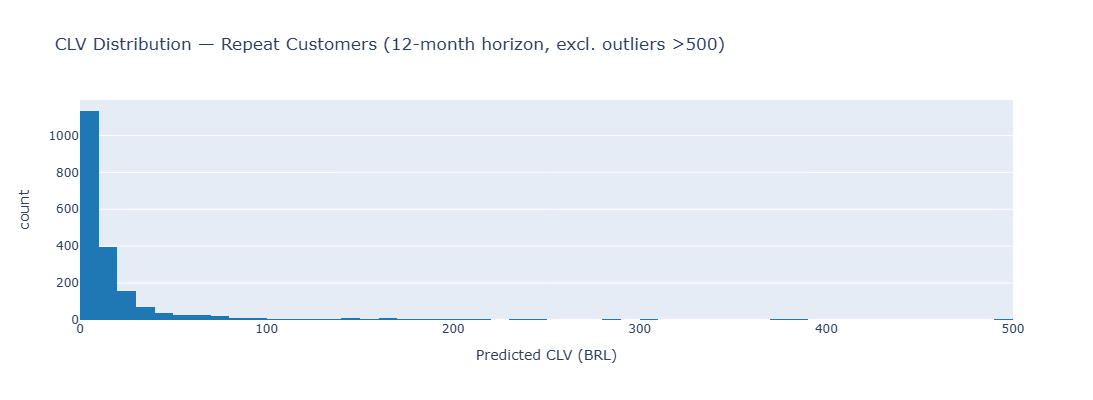

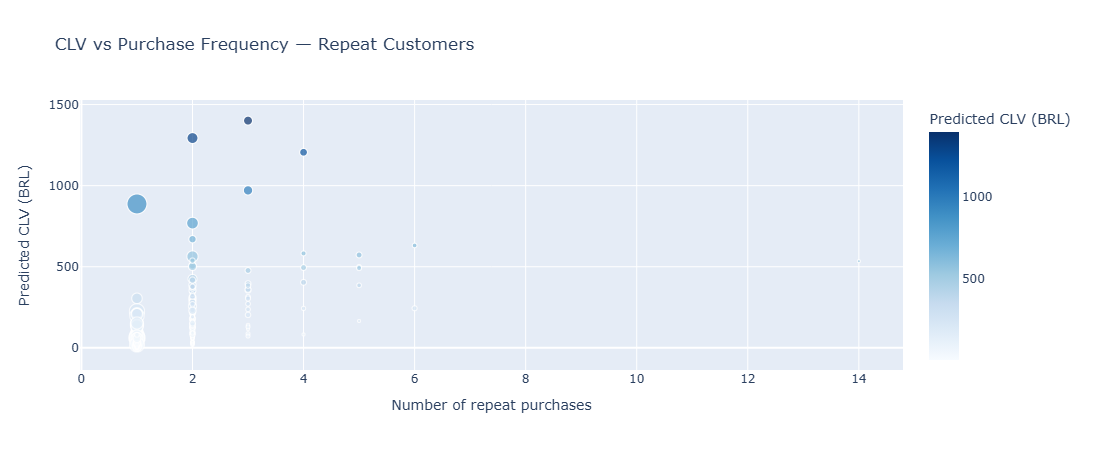

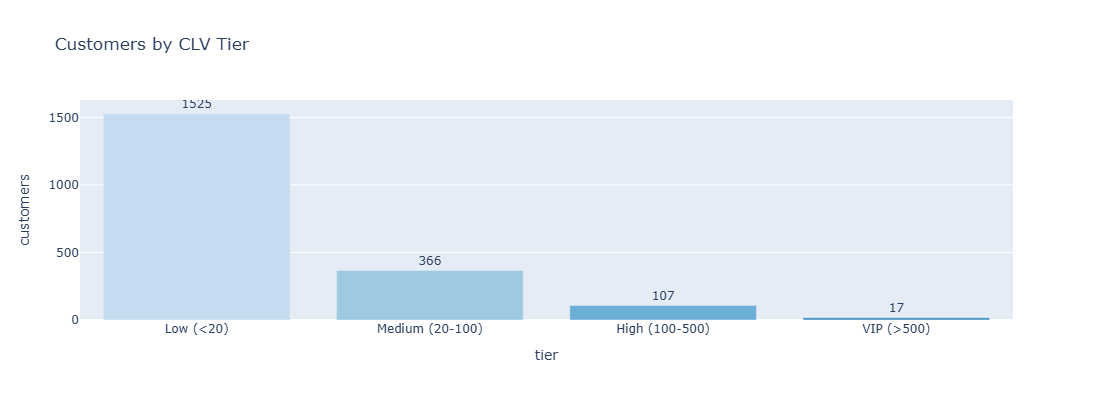

In [8]:
# Chart 1: CLV distribution
fig1 = px.histogram(
    clv_df[clv_df["clv_12m"] < 500],  # exclude outliers for readability
    x="clv_12m",
    nbins=50,
    title="CLV Distribution — Repeat Customers (12-month horizon, excl. outliers >500)",
    labels={"clv_12m": "Predicted CLV (BRL)"},
    color_discrete_sequence=["#1f77b4"]
)
fig1.update_layout(height=400)
fig1.show()

# Chart 2: CLV vs frequency
fig2 = px.scatter(
    clv_df,
    x="frequency",
    y="clv_12m",
    size="monetary_value",
    color="clv_12m",
    color_continuous_scale="Blues",
    title="CLV vs Purchase Frequency — Repeat Customers",
    labels={"frequency": "Number of repeat purchases",
            "clv_12m": "Predicted CLV (BRL)",
            "monetary_value": "Avg order value"}
)
fig2.update_layout(height=450)
fig2.show()

# Chart 3: CLV tiers
clv_df["clv_tier"] = pd.cut(
    clv_df["clv_12m"],
    bins=[0, 20, 100, 500, 99999],
    labels=["Low (<20)", "Medium (20-100)", "High (100-500)", "VIP (>500)"]
)
tier_summary = clv_df["clv_tier"].value_counts().reset_index()
tier_summary.columns = ["tier", "customers"]

fig3 = px.bar(
    tier_summary.sort_values("tier"),
    x="tier",
    y="customers",
    color="tier",
    text="customers",
    title="Customers by CLV Tier",
    color_discrete_sequence=px.colors.sequential.Blues[2:]
)
fig3.update_traces(textposition="outside")
fig3.update_layout(height=400, showlegend=False)
fig3.show()

In [9]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

fig1.write_html("../docs/screenshots/03_clv_distribution.html")
fig2.write_html("../docs/screenshots/03_clv_vs_frequency.html")
fig3.write_html("../docs/screenshots/03_clv_tiers.html")

clv_df.to_csv("../data/processed/03_clv_scores.csv")

print("Saved all outputs")

Saved all outputs


In [10]:
tier_counts = clv_df["clv_tier"].value_counts()

print("CUSTOMER LIFETIME VALUE SUMMARY")
print(f"Model          : BG/NBD + Gamma-Gamma")
print(f"Horizon        : 12 months")
print(f"Discount rate  : 1% monthly")
print(f"Repeat buyers  : {len(clv_df):,} ({len(clv_df)/len(summary)*100:.1f}% of all customers)")
print()
print("CLV Tiers:")
for tier, count in tier_counts.items():
    pct = count / len(clv_df) * 100
    print(f"  {str(tier):<20} {count:>5,} customers ({pct:.1f}%)")
print()
print(f"Mean CLV  : BRL {clv_df['clv_12m'].mean():.2f}")
print(f"Median CLV: BRL {clv_df['clv_12m'].median():.2f}")
print(f"Max CLV   : BRL {clv_df['clv_12m'].max():.2f}")
print()
print("FINDINGS:")
print("1. Only 2.2% of customers make repeat purchases")
print("2. Mean 12-month CLV is BRL 30.86 across repeat buyers")
print("3. VIP tier (>500 BRL CLV) = top customers to protect")
print("4. High CLV correlates with both frequency AND order value")

CUSTOMER LIFETIME VALUE SUMMARY
Model          : BG/NBD + Gamma-Gamma
Horizon        : 12 months
Discount rate  : 1% monthly
Repeat buyers  : 2,015 (2.2% of all customers)

CLV Tiers:
  Low (<20)            1,525 customers (75.7%)
  Medium (20-100)        366 customers (18.2%)
  High (100-500)         107 customers (5.3%)
  VIP (>500)              17 customers (0.8%)

Mean CLV  : BRL 30.86
Median CLV: BRL 8.64
Max CLV   : BRL 1400.89

FINDINGS:
1. Only 2.2% of customers make repeat purchases
2. Mean 12-month CLV is BRL 30.86 across repeat buyers
3. VIP tier (>500 BRL CLV) = top customers to protect
4. High CLV correlates with both frequency AND order value


In [11]:
con.close()
print("Connection closed")

Connection closed
